<a href="https://colab.research.google.com/github/RenteriaRaul/Doctorado-DCAG/blob/main/notebooks/sustax/05_sustax_future_projection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Configuración**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
import os
import pandas as pd
from IPython.display import Image, display

PROJECT_PATH = "/content/drive/MyDrive/Doctorado-DCAG"
os.chdir(PROJECT_PATH)
sys.path.append(PROJECT_PATH)

print("Working directory:", os.getcwd())

Mounted at /content/drive
Working directory: /content/drive/MyDrive/Doctorado-DCAG


# **Imports**

In [2]:
from scripts.sustax.projection import (
    build_future_projection_summary,
    build_annual_projection_2027_2040,
    plot_future_signal_by_scenario,
    plot_future_signal_by_point,
    plot_annual_series_by_point,
    plot_regional_mean_annual_max,
)

# **Configuración**

In [3]:
PROJECT_DIR = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación"
SUSTAX_DIR = os.path.join(PROJECT_DIR, "Datos Sustax")
BYSCEN_TOTAL_FOLDER = os.path.join(SUSTAX_DIR, "SUSTAX_TOTAL_MERGED", "BY_SCENARIO_TOTAL")

OUT_FOLDER = os.path.join(SUSTAX_DIR, "PHASE_C_FUTURE_SSP")
OUT_FOLDER_2027_2040 = os.path.join(SUSTAX_DIR, "PHASE_C_FUTURE_SSP_2027_2040")

os.makedirs(OUT_FOLDER, exist_ok=True)
os.makedirs(OUT_FOLDER_2027_2040, exist_ok=True)

POINTS_TO_USE = [
    "Sustax_ Manzanillo_LosReyesTotal",
    "Sustax_ManzanilloTotal",
    "Sustax_MinatitlanTotal",
    "Sustax_TecomanTotal",
    "Sustax_TolimanTotal",
    "Sustax_Veladero_de_OtatesTotal",
    "Sustax_VilladeAlvarezTotal",
    "Sustax_Zapotitlan_de_VadilloTotal",
]

SSP_LIST = ["SSP119", "SSP126", "SSP245", "SSP370", "SSP434", "SSP460", "SSP585"]

SCENARIO_COLORS = {
    "SSP119": "#17becf",
    "SSP126": "#8c564b",
    "SSP245": "#2ca02c",
    "SSP370": "#d62728",
    "SSP434": "#bcbd22",
    "SSP460": "#7f7f7f",
    "SSP585": "#9467bd",
}

# **Resumen histórico vs futuro**



In [4]:
df_future_ssp, table_top_intensification, table_scenario_signal, table_point_signal = build_future_projection_summary(
    byscen_total_folder=BYSCEN_TOTAL_FOLDER,
    out_folder=OUT_FOLDER,
    ssp_list=SSP_LIST,
    hist_start=1980,
    hist_end=2014,
    fut1_start=2015,
    fut1_end=2049,
    fut2_start=2050,
    fut2_end=2080,
)

display(df_future_ssp.head())
display(table_top_intensification.head())
display(table_scenario_signal.head())
display(table_point_signal.head())

,sustax_total,scenario,hist_mean_daily_mm,hist_p95_daily_mm,hist_p99_daily_mm,hist_max_daily_mm,fut1_mean_daily_mm,fut1_p95_daily_mm,fut1_p99_daily_mm,fut1_max_daily_mm,...,delta_fut2_mean_daily_mm,pct_fut2_mean_daily,delta_fut2_p95_daily_mm,pct_fut2_p95_daily,delta_fut2_p99_daily_mm,pct_fut2_p99_daily,delta_fut2_mean_monthly_max_mm,pct_fut2_mean_monthly_max,delta_fut2_p95_monthly_max_mm,pct_fut2_p95_monthly_max
0,Sustax_ Manzanillo_LosReyesTotal,SSP119,3.306019,15.153906,39.708637,304.593086,3.234489,15.425026,41.785720,300.671369,...,-0.461931,-13.972438,-0.545403,-3.599092,-4.994550,-12.577993,-8.352436,-30.709941,-21.772768,-22.581232
1,Sustax_ Manzanillo_LosReyesTotal,SSP126,3.021925,13.988601,36.563134,301.587850,3.291520,15.821519,40.161911,304.593086,...,-0.512750,-16.967648,-1.314445,-9.396547,-5.726971,-15.663237,-7.073248,-30.080295,-11.940321,-12.804587
2,Sustax_ Manzanillo_LosReyesTotal,SSP245,2.966319,13.895094,36.219852,304.032594,3.367883,16.022870,40.588782,304.593086,...,-0.667951,-22.517838,-2.466354,-17.749817,-6.834006,-18.868122,-8.791309,-40.073776,-10.032739,-12.334549
3,Sustax_ Manzanillo_LosReyesTotal,SSP370,3.087452,14.508391,36.910810,304.593086,3.329992,15.654475,40.120163,293.944746,...,-0.941063,-30.480260,-3.814030,-26.288441,-8.790206,-23.814719,-10.483505,-45.853375,-35.884715,-39.397478
4,Sustax_ Manzanillo_LosReyesTotal,SSP434,3.182060,16.012259,37.279402,221.203223,3.304987,16.462318,41.569082,321.838230,...,-0.131780,-4.141332,-1.137924,-7.106577,1.205000,3.232348,0.954653,4.069552,-10.029970,-9.019091


,sustax_total,scenario,hist_p95_monthly_max_mm,fut2_p95_monthly_max_mm,delta_fut2_p95_monthly_max_mm,pct_fut2_p95_monthly_max
0,Sustax_VilladeAlvarezTotal,SSP434,64.006938,91.520451,27.513513,42.985203
1,Sustax_TecomanTotal,SSP434,78.542441,98.020813,19.478373,24.799806
2,Sustax_Zapotitlan_de_VadilloTotal,SSP434,50.390106,59.883896,9.493790,18.840583
3,Sustax_TolimanTotal,SSP434,52.557316,60.600712,8.043396,15.304046
4,Sustax_CuautitlanTotal,SSP434,60.333020,69.223292,8.890272,14.735335


,scenario,pct_fut1_p95_daily,pct_fut2_p95_daily,pct_fut1_p95_monthly_max,pct_fut2_p95_monthly_max
4,SSP434,-1.056205,-4.481500,36.694906,15.308566
1,SSP126,11.893160,-8.085156,7.891875,-7.781396
2,SSP245,17.737010,-15.438548,26.683223,-10.958692
0,SSP119,1.845315,-3.392568,6.479365,-13.068120
5,SSP460,-1.509262,-6.852866,-11.063804,-14.917923


,sustax_total,pct_fut1_p95_daily,pct_fut2_p95_daily,pct_fut1_p95_monthly_max,pct_fut2_p95_monthly_max
10,Sustax_VilladeAlvarezTotal,9.150642,-16.448754,34.495969,-4.821917
11,Sustax_Zapotitlan_de_VadilloTotal,4.082419,-7.670184,24.534000,-7.187121
8,Sustax_TolimanTotal,3.804841,-8.944647,28.535265,-8.786670
9,Sustax_Veladero_de_OtatesTotal,8.380599,-10.597442,16.884771,-9.555238
4,Sustax_MinatitlanTotal,4.370226,-11.350834,21.773158,-14.399523


# **Figuras de señal futura**

In [5]:
fig_scenario = os.path.join(OUT_FOLDER, "future_signal_by_scenario.png")
fig_point = os.path.join(OUT_FOLDER, "future_signal_by_point.png")

plot_future_signal_by_scenario(table_scenario_signal, fig_scenario)
plot_future_signal_by_point(table_point_signal, fig_point)

print("Figuras generadas:")
print(fig_scenario)
print(fig_point)

Figuras generadas:
/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/PHASE_C_FUTURE_SSP/future_signal_by_scenario.png
/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/PHASE_C_FUTURE_SSP/future_signal_by_point.png


# **Proyección anual 2027–2040**

In [6]:
df_proj_annual, df_proj_scenario_year, df_proj_point_scenario = build_annual_projection_2027_2040(
    byscen_total_folder=BYSCEN_TOTAL_FOLDER,
    out_folder=OUT_FOLDER_2027_2040,
    points_to_use=POINTS_TO_USE,
    ssp_list=SSP_LIST,
    year_start=2027,
    year_end=2040,
)

display(df_proj_annual.head())
display(df_proj_scenario_year.head())
display(df_proj_point_scenario.head())

,sustax_total,scenario,year,annual_total_mm,annual_mean_daily_mm,annual_p95_daily_mm,annual_p99_daily_mm,annual_max_daily_mm,annual_mean_monthly_max_mm,annual_max_monthly_max_mm,n_days
0,Sustax_ Manzanillo_LosReyesTotal,SSP119,2027,1089.494561,2.984917,12.761930,27.303710,214.863524,27.968806,214.863524,365
1,Sustax_ Manzanillo_LosReyesTotal,SSP119,2028,1033.113294,2.822714,14.641162,40.136765,76.896183,17.634568,76.896183,366
2,Sustax_ Manzanillo_LosReyesTotal,SSP119,2029,2379.901318,6.520278,26.739527,137.680767,260.748506,46.038217,260.748506,365
3,Sustax_ Manzanillo_LosReyesTotal,SSP119,2030,999.799049,2.739175,12.090627,32.029027,106.463984,22.884939,106.463984,365
4,Sustax_ Manzanillo_LosReyesTotal,SSP119,2031,866.350504,2.373563,12.394425,36.392993,84.269531,18.418670,84.269531,365


,scenario,year,annual_total_mm,annual_mean_daily_mm,annual_p95_daily_mm,annual_p99_daily_mm,annual_max_daily_mm,annual_mean_monthly_max_mm,annual_max_monthly_max_mm
0,SSP119,2027,1089.417017,2.984704,13.687028,27.030601,98.685308,16.672039,98.685308
1,SSP119,2028,975.653976,2.665721,12.668666,24.408781,51.332118,11.897758,51.332118
2,SSP119,2029,2039.545458,5.587796,23.000759,99.280975,179.849976,36.797789,179.849976
3,SSP119,2030,1156.067578,3.167308,12.676487,28.678649,124.827916,25.696317,124.827916
4,SSP119,2031,924.000474,2.531508,11.646148,26.572581,56.338414,13.862372,56.338414


,sustax_total,scenario,annual_total_mm,annual_mean_daily_mm,annual_p95_daily_mm,annual_p99_daily_mm,annual_max_daily_mm,annual_mean_monthly_max_mm,annual_max_monthly_max_mm
0,Sustax_ Manzanillo_LosReyesTotal,SSP119,1205.433745,3.300165,15.820338,44.240308,123.432226,24.135090,123.432226
1,Sustax_ Manzanillo_LosReyesTotal,SSP126,1257.634532,3.442871,16.693330,42.306369,110.128899,19.947283,110.128899
2,Sustax_ Manzanillo_LosReyesTotal,SSP245,1164.554697,3.188016,15.479434,38.573146,103.358384,18.568894,103.358384
3,Sustax_ Manzanillo_LosReyesTotal,SSP370,1270.367472,3.477475,16.711050,41.032523,115.437242,23.064867,115.437242
4,Sustax_ Manzanillo_LosReyesTotal,SSP434,1192.580277,3.264458,16.304135,37.691404,114.198950,25.978222,114.198950


# **Figuras anuales**

In [8]:
plot_annual_series_by_point(
    df_proj_annual=df_proj_annual,
    out_folder=OUT_FOLDER_2027_2040,
    ssp_list=SSP_LIST,
    scenario_colors=SCENARIO_COLORS,
)

regional_fig = os.path.join(OUT_FOLDER_2027_2040, "regionals_mean_annual_max_daily_2027_2040.png")
plot_regional_mean_annual_max(
    df_proj_scenario_year=df_proj_scenario_year,
    out_fp=regional_fig,
    ssp_list=SSP_LIST,
    scenario_colors=SCENARIO_COLORS,
)

print("Figuras anuales generadas.")
print(regional_fig)

Figuras anuales generadas.
/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/PHASE_C_FUTURE_SSP_2027_2040/regionals_mean_annual_max_daily_2027_2040.png


# **Mostrar imágenes clave**


Figura: future_signal_by_scenario.png
Existe: True


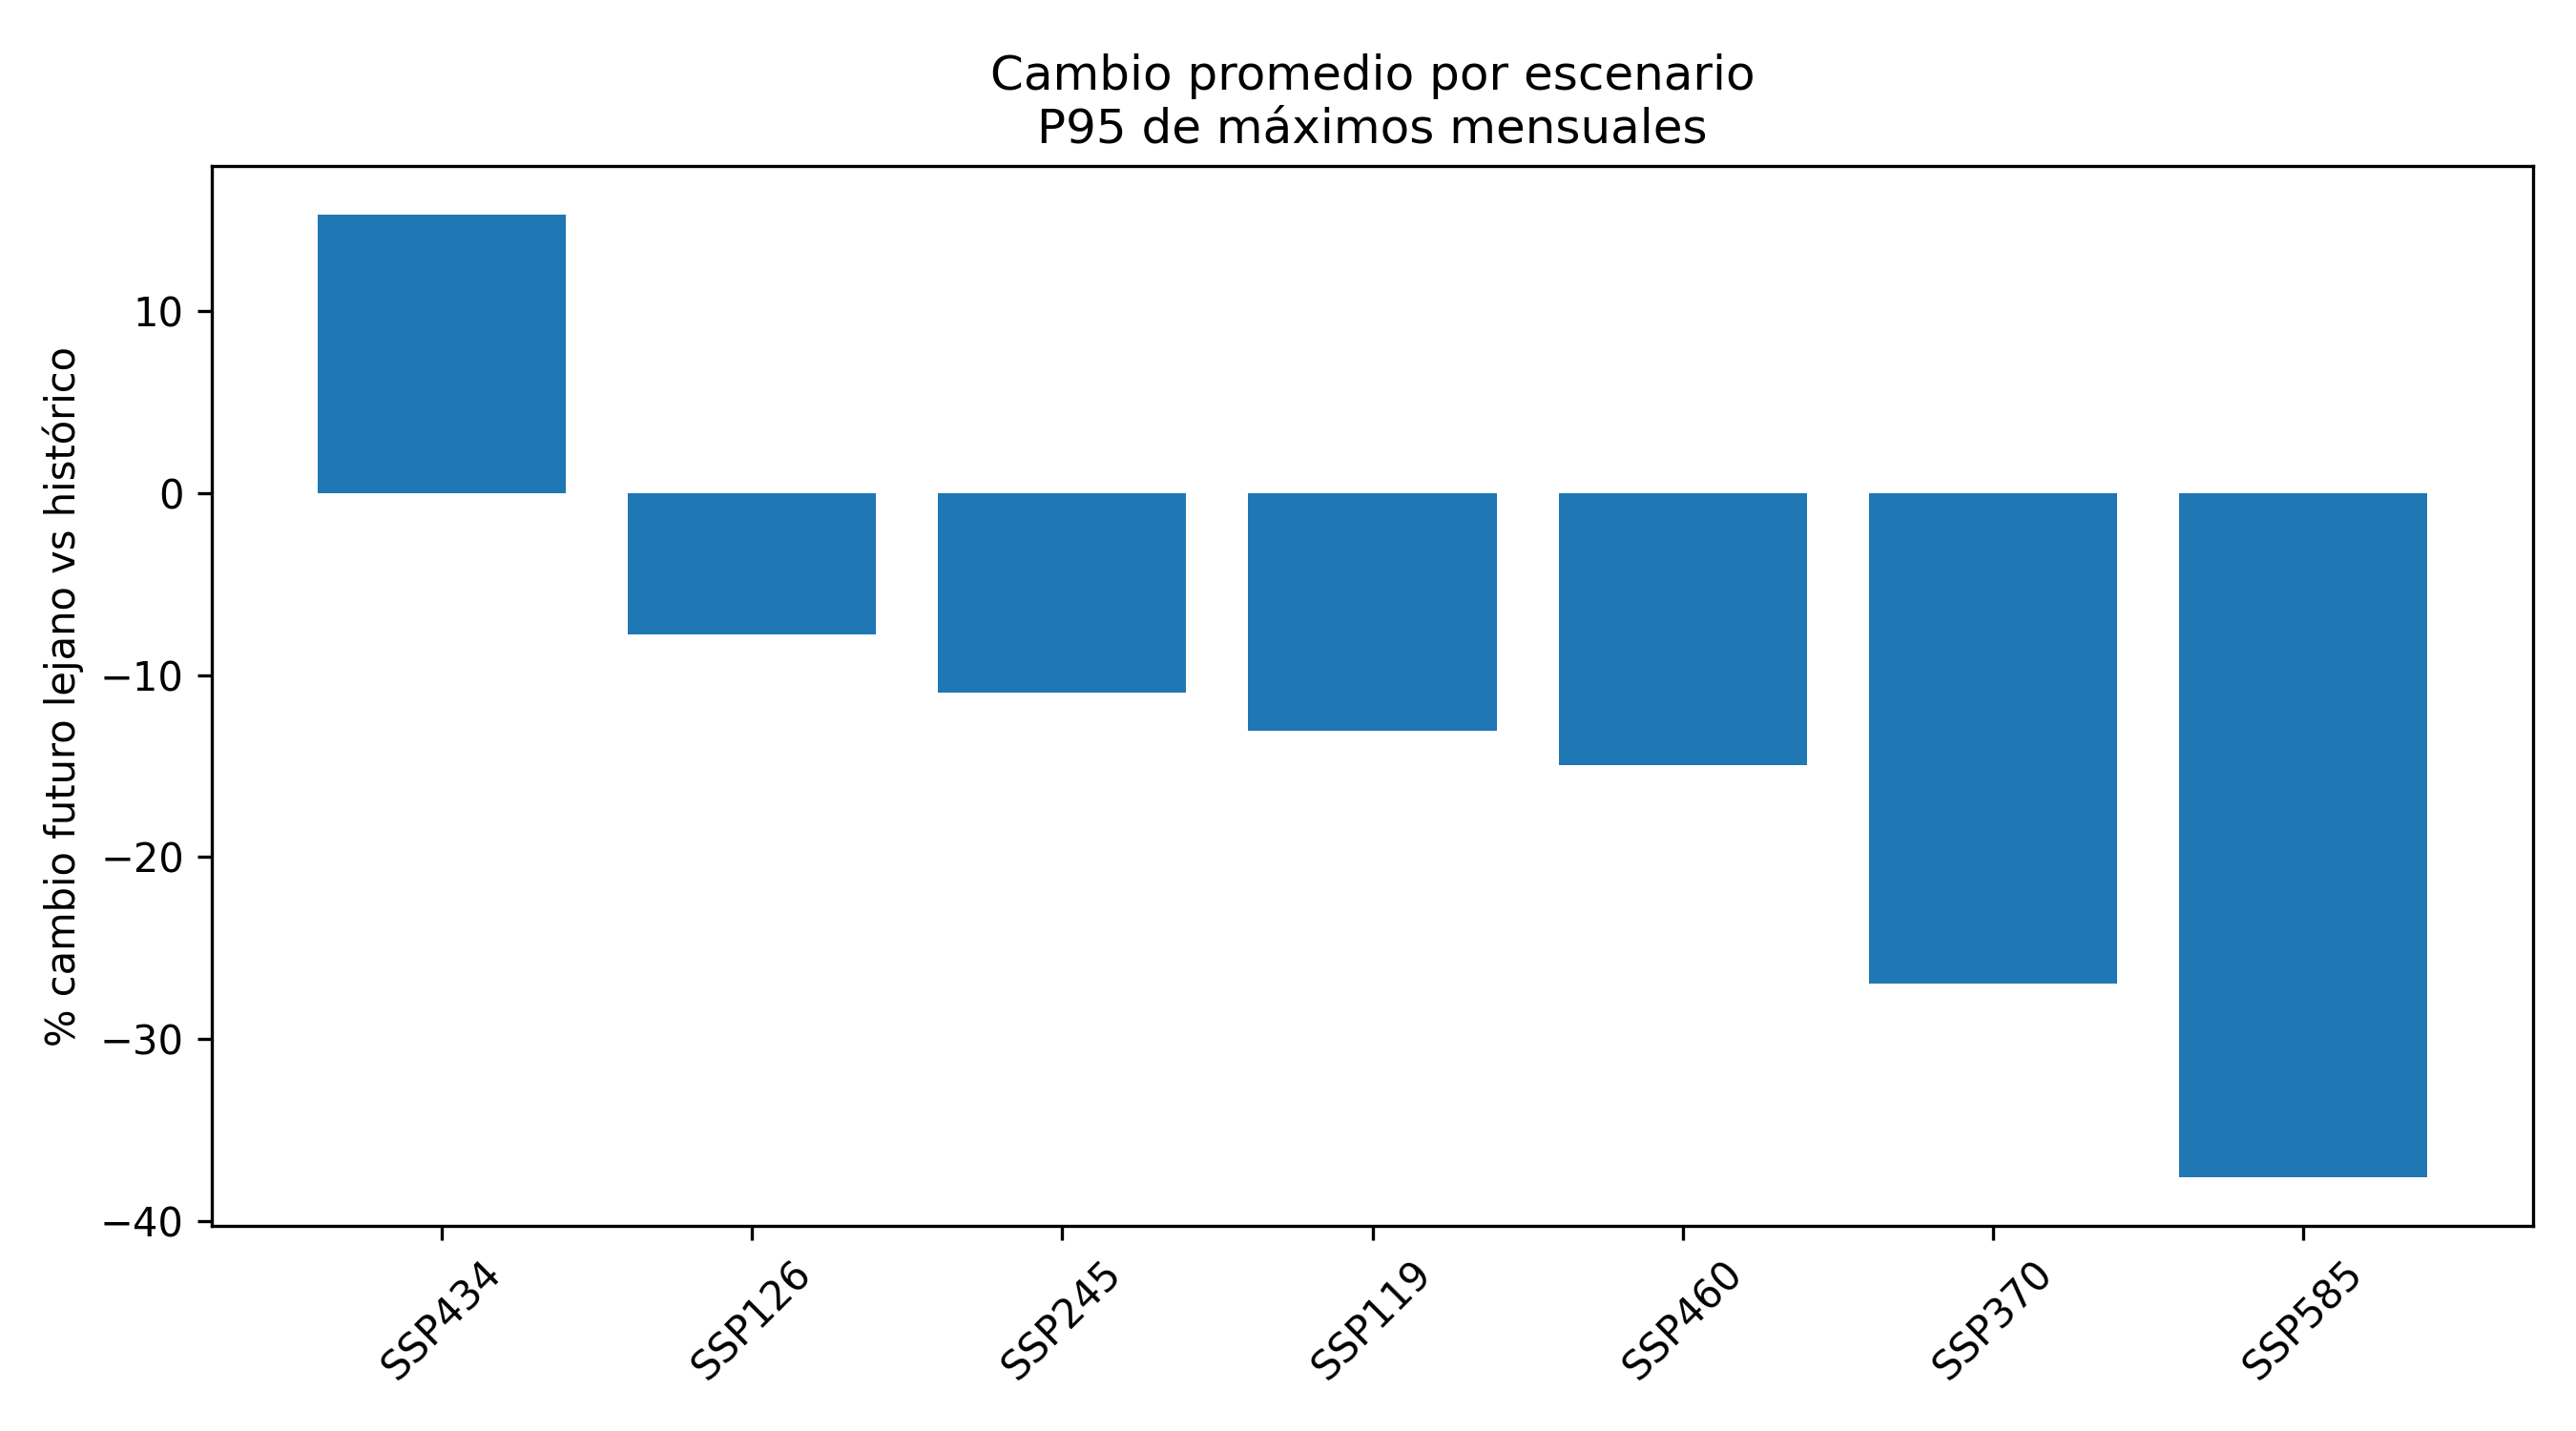


Figura: future_signal_by_point.png
Existe: True


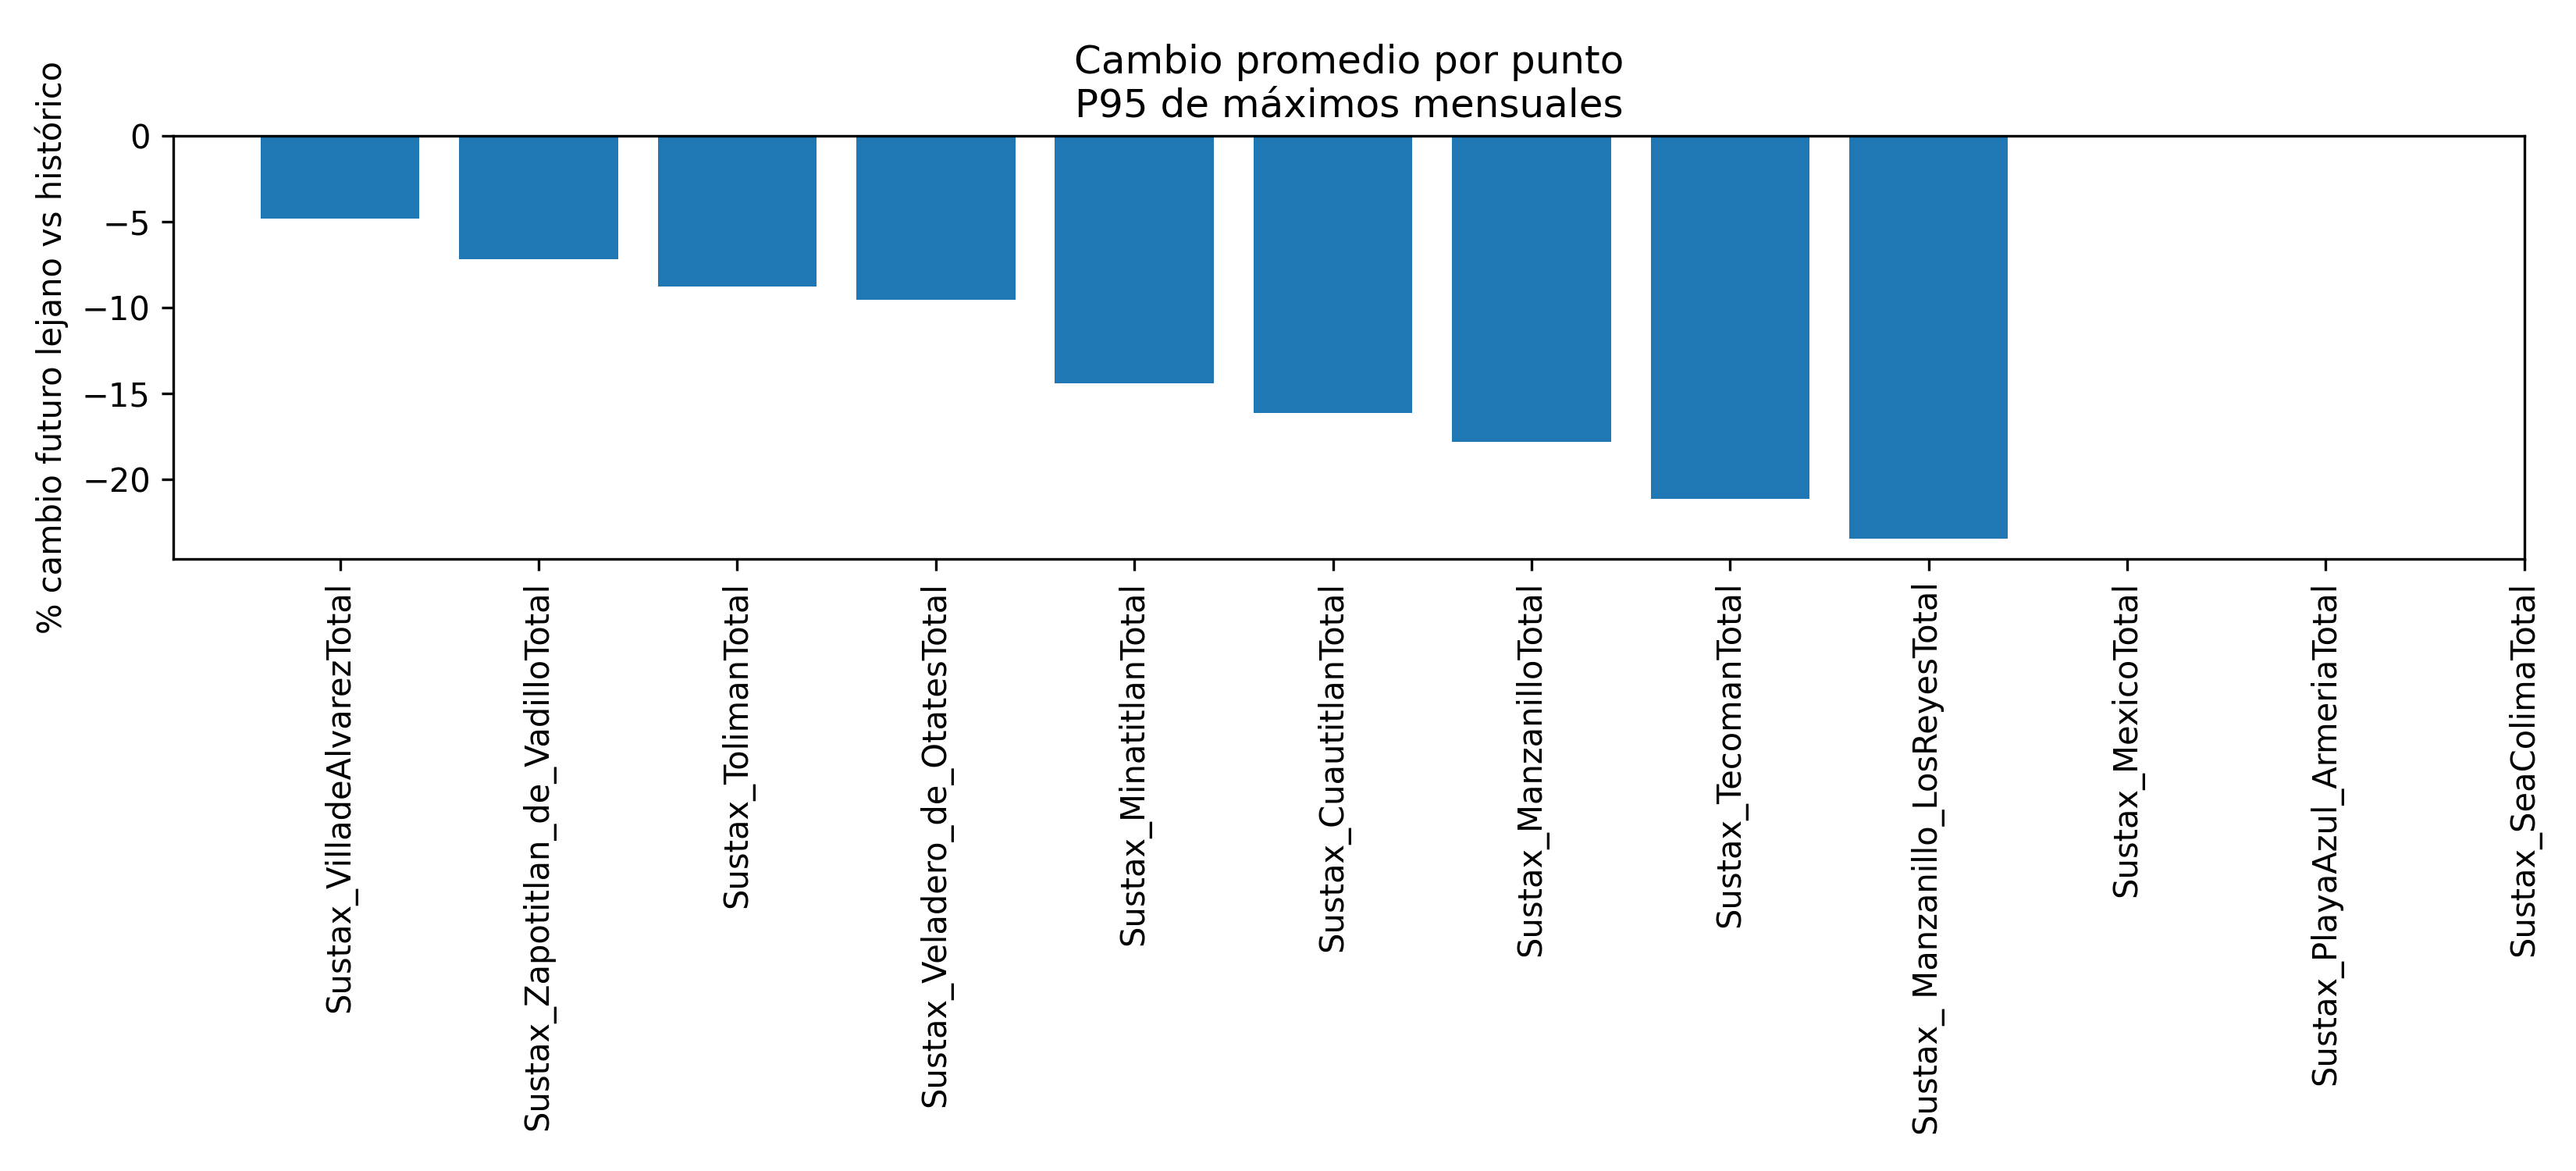


Figura: regional_mean_annual_max_daily_2027_2040.png
Existe: True


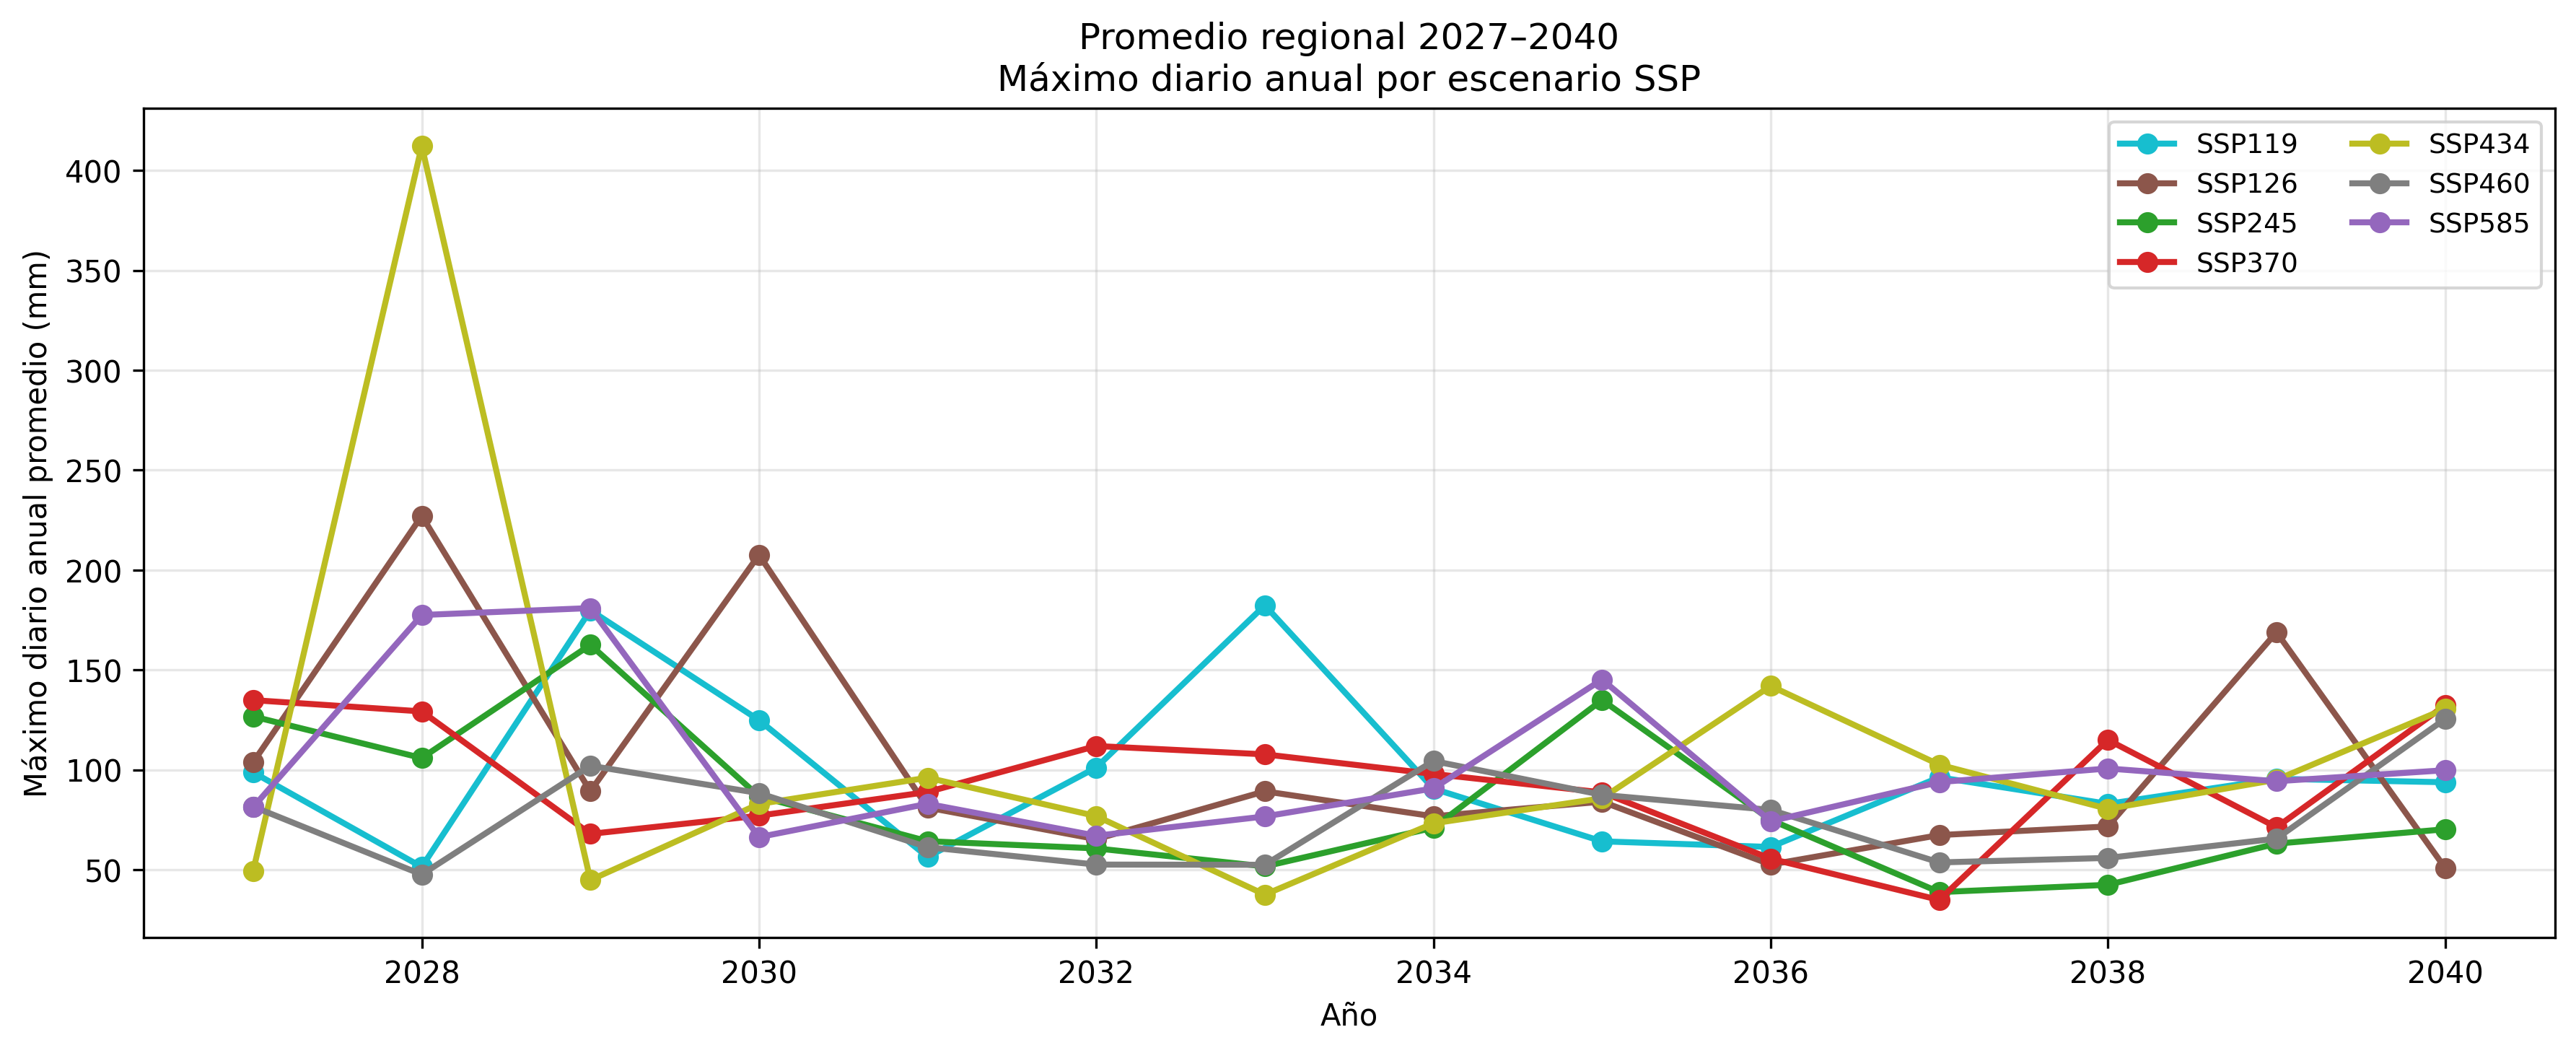

In [9]:
figuras_clave = [
    os.path.join(OUT_FOLDER, "future_signal_by_scenario.png"),
    os.path.join(OUT_FOLDER, "future_signal_by_point.png"),
    os.path.join(OUT_FOLDER_2027_2040, "regional_mean_annual_max_daily_2027_2040.png"),
]

for fp in figuras_clave:
    print("\nFigura:", os.path.basename(fp))
    print("Existe:", os.path.exists(fp))
    if os.path.exists(fp):
        display(Image(filename=fp))